# Student 3: GAM - Telco Customer Churn

Predicting churn with a Logistic GAM.

## 1. Load and clean data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

from pygam import LogisticGAM, s, f

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df = df.drop(columns=["customerID"])

# TotalCharges is stored as text and has some blank values -> convert and drop them
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=["TotalCharges"])

# target as 0/1
df["Churn"] = (df["Churn"] == "Yes").astype(int)

df.shape

(7032, 20)

In [3]:
num_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
]

# pygam needs numeric input, so encode each categorical as integer codes
df_enc = df.copy()
for c in cat_cols:
    df_enc[c] = df_enc[c].astype("category").cat.codes

feature_cols = num_cols + cat_cols
X = df_enc[feature_cols].values
y = df_enc["Churn"].values
col_idx = {c: i for i, c in enumerate(feature_cols)}

## 2. EDA relevant to GAM assumptions


Checking two assumptions before modeling:

1. Does churn rate change smoothly/non-linearly with a numeric feature (like tenure), or is it roughly a straight line? If it curves, a GAM's spline term is a better fit than a single linear coefficient.
2. Are any numeric features highly correlated with each other? High correlation can make individual feature effects unstable/hard to interpret, even if overall predictions are fine.

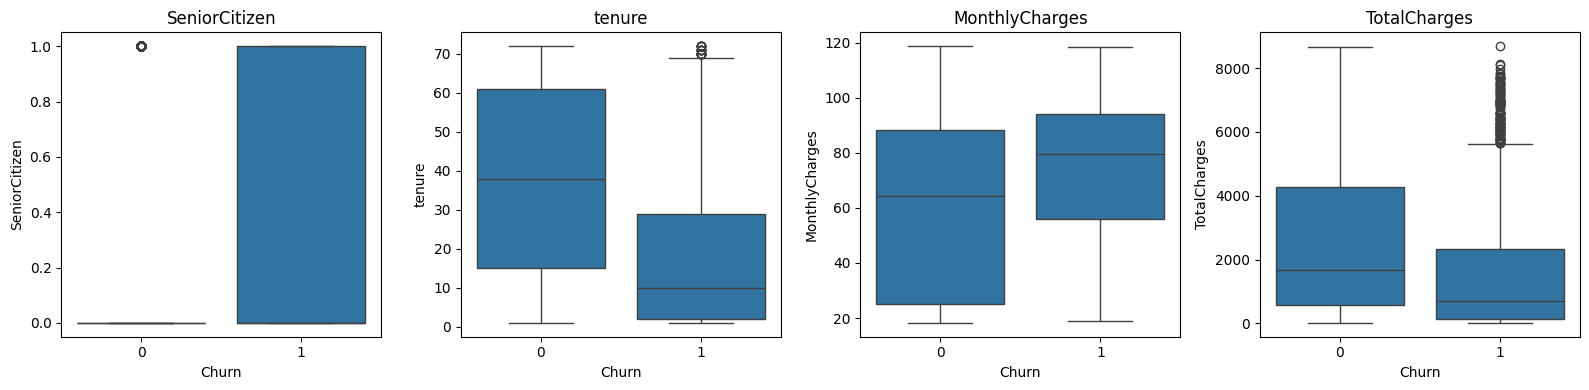

In [4]:
# checking how the numeric features differ between churners/non-churners

fig, axes = plt.subplots(1, len(num_cols), figsize=(16, 4))
for ax, c in zip(axes, num_cols):
    sns.boxplot(x="Churn", y=c, data=df, ax=ax)
    ax.set_title(c)
plt.tight_layout()
plt.show()

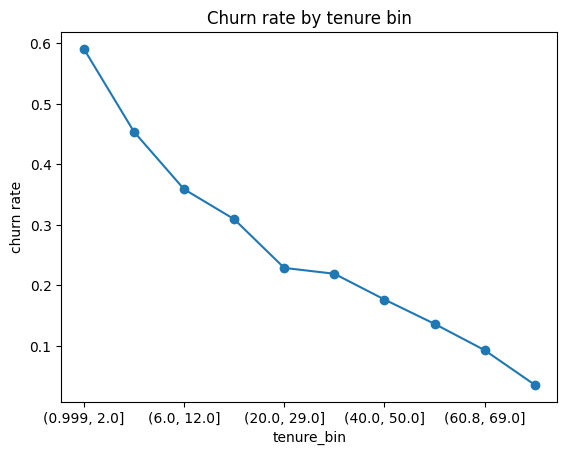

In [5]:
# bin tenure and look at the churn rate per bin -- check if it looks like a straight line or a curve
tmp = df.copy()
tmp["tenure_bin"] = pd.qcut(tmp["tenure"], q=10)
tmp.groupby("tenure_bin", observed=True)["Churn"].mean().plot(marker="o")
plt.ylabel("churn rate")
plt.title("Churn rate by tenure bin")
plt.show()

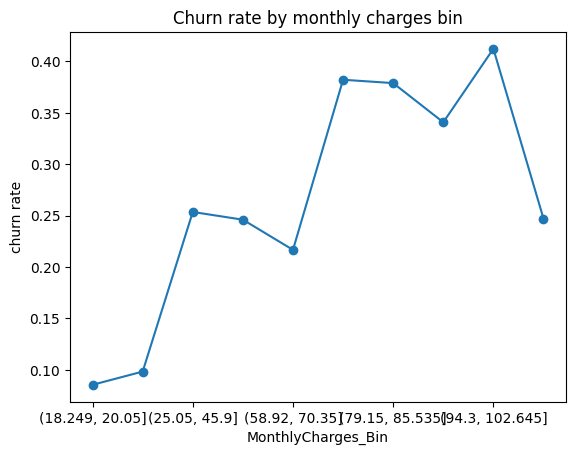

In [6]:
# bin MonthlyCharges and look at the churn rate per bin -- check if it looks like a straight line or a curve
tmp = df.copy()
tmp["MonthlyCharges_Bin"] = pd.qcut(tmp["MonthlyCharges"], q=10)
tmp.groupby("MonthlyCharges_Bin", observed=True)["Churn"].mean().plot(marker="o")
plt.ylabel("churn rate")
plt.title("Churn rate by monthly charges bin")
plt.show()

In [7]:
df[num_cols].corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
MonthlyCharges,0.219874,0.246862,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


The boxplots show churners tend to have lower `tenure` and `TotalCharges`, but higher `MonthlyCharges` than non-churners. The tenure-bin plot confirms churn rate drops off in a curve, not a straight line -- supports using a smooth term instead of a linear one. `tenure` and `TotalCharges` are highly correlated (0.83), which makes sense since longer customers have paid more overall.

## 3. GAM model

* GAMs model the outcome as a sum of functions of each feature, instead of one linear combination
* uses splines so each feature's relationship with the outcome can be non-linear (or non-linear per category)

#### Terminology
* LogisticGAM: binomial/logit link, used here since Churn is 0/1
* s(*i*): spline term for feature *i*, lets that feature have a curved (non-linear) effect
* f(*i*): factor term for feature *i*, fits a separate effect per category (used for our categorical columns)

Using the pygam library. Docs [here](https://pygam.readthedocs.io/en/latest/notebooks/tour_of_pygam.html).

* gridsearch searches over smoothing parameter values and picks the one that minimizes cross-validation error on the training data

In [8]:
# splitting the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

terms = None
for c in num_cols:
    t = s(col_idx[c])
    terms = t if terms is None else terms + t
for c in cat_cols:
    terms = terms + f(col_idx[c])

gam = LogisticGAM(terms)
gam.gridsearch(X_train, y_train)
gam.summary()

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:02
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:01
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:01
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:00
 45% (5 of 11) |###########              | Elapsed Time: 0:00:00 ETA:   0:00:00
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:   0:00:00
 63% (7 of 11) |###############          | Elapsed Time: 0:00:00 ETA:   0:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                     37.0064
Link Function:                        LogitLink Log Likelihood:                                 -2265.6257
Number of Samples:                         5625 AIC:                                             4605.2641
                                                AICc:                                            4605.7949
                                                UBRE:                                                2.824
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.3044
Feature Function                  Lam

/var/folders/d9/jrdhm0fs42jgp293l0fm5cnm0000gn/T/ipykernel_28921/3754003780.py:15: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


## 4. Performance

In [9]:
pred_proba = gam.predict_proba(X_test)
pred = (pred_proba >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, pred))
print("AUC:", roc_auc_score(y_test, pred_proba))
print(classification_report(y_test, pred))
confusion_matrix(y_test, pred)

Accuracy: 0.8024164889836531
AUC: 0.8406347226032893
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.65      0.54      0.59       374

    accuracy                           0.80      1407
   macro avg       0.75      0.72      0.73      1407
weighted avg       0.79      0.80      0.80      1407



array([[926, 107],
       [171, 203]])

~80% accuracy, 0.84 AUC. Recall on churners (class 1) is only 0.54, much lower than non-churners (0.90) -- the model misses a lot of actual churners, likely due to the class imbalance (1033 vs 374 in the test set).

From the summary table, `s(0)`-`s(3)` (the numeric features) are all significant, and most factor terms are too, though `f(4)`/`f(5)` (gender, Partner) look weak.

## 5. Smooth effects

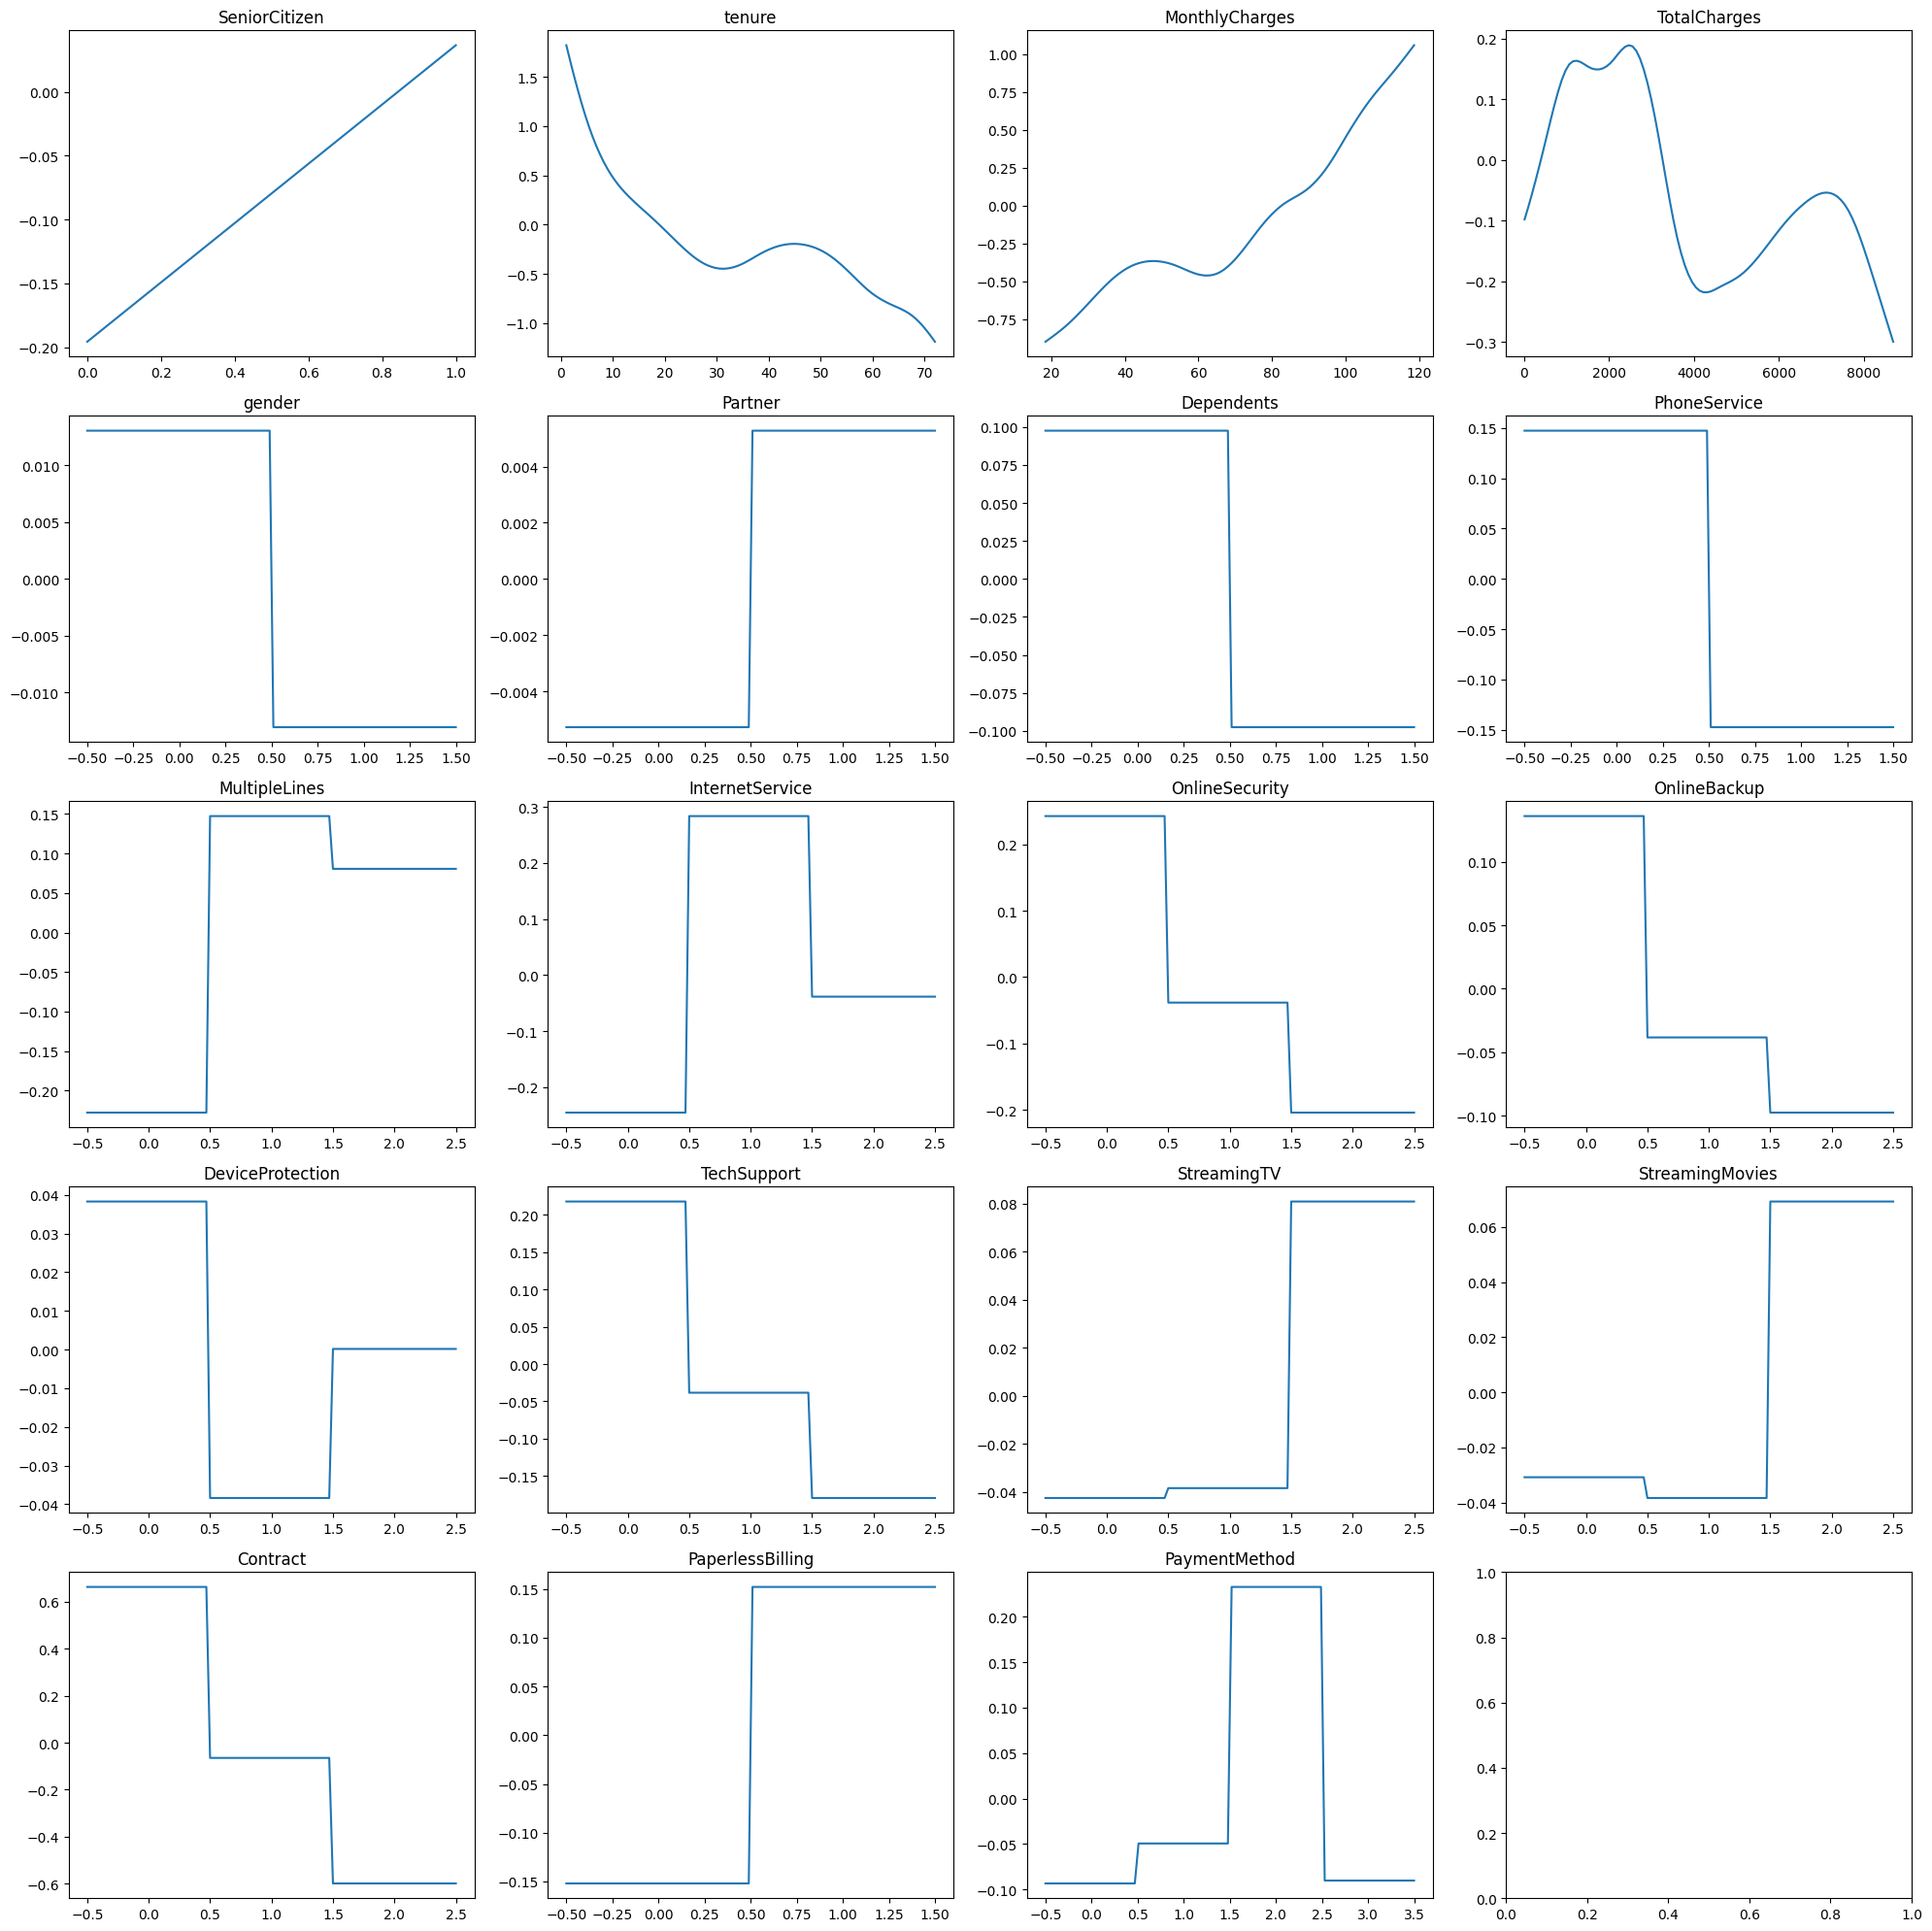

In [10]:
fig, axes = plt.subplots(5, 4, figsize=(20, 20))
axes = axes.ravel()
for i, term in enumerate(gam.terms):
    if term.isintercept:
        continue
    XX = gam.generate_X_grid(term=i)
    pdep = gam.partial_dependence(term=i, X=XX)
    axes[i].plot(XX[:, term.feature], pdep)
    axes[i].set_title(feature_cols[i])
plt.tight_layout()
plt.show()

- `tenure`: drops sharply then flattens -- new customers churn much more than long-time ones.
- `MonthlyCharges`: mostly increasing -- higher bills push churn risk up, with a small dip/plateau in the mid-range.
- `TotalCharges`: wiggly, but overall low-to-mid range has a mild positive bump then drops off at the highest values.
- `Contract`: month-to-month has the highest effect, one-year is near zero, two-year is clearly negative -- longer contracts strongly reduce churn.
- Several factor terms (gender, Partner, Dependents, DeviceProtection) have tiny effects near zero -- these features don't seem to matter much once everything else is in the model.

## 6. Limitation

A GAM assumes the total effect on churn is just the sum of each feature's individual effect -- it can't capture interactions unless you explicitly add them. For example, the model treats tenure's effect as the same regardless of Contract type, but in reality a long-tenure customer on a month-to-month contract might behave very differently from a long-tenure customer locked into a two-year contract. If that kind of interaction matters, this model is missing it.

Also, the smooth terms for `TotalCharges` and a couple of others (see the partial dependence plots) look wiggly rather than smooth -- possibly overfitting on a feature that's highly correlated with `tenure`.

Adding interaction terms could fix the first issue, but each interaction added makes the model harder to visualize and explain -- part of the tradeoff between flexibility and interpretability that motivated using a GAM in the first place.